In [1]:
import os

import scipy
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Style and plot settings
plt.style.use("ggplot")

COLOR = "red"
ALPHA_MEAN = 0.9
ALPHA_STD = 0.1
AVG_FILTER_SIZE = 5

In [3]:
def load_data(env_id: str) -> pd.DataFrame:
    files = [x for x in os.listdir() if env_id in x and x.endswith(".csv")]
    dfs = [pd.read_csv(f) for f in files]
    
    df_out = pd.DataFrame() 
    df_out["t"] = dfs[0]["t"]

    stacked_means = pd.concat([df["average_return"] for df in dfs], axis=1)
    df_out["average_return"] = stacked_means.mean(axis=1)  
    df_out["std_return"] = stacked_means.std(axis=1, ddof=1)  

    return df_out

## LunarLander-v3

In [4]:
data = load_data("LunarLander-v3")
data.head(-1)

,t,average_return,std_return
0,65536,-511.794080,183.580723
1,131072,-173.413859,101.546690
2,196608,-182.930255,113.302373
3,262144,-128.935057,120.913538
4,327680,-210.582754,233.312879
5,393216,-287.598080,257.167612
6,458752,-305.673315,297.688404
7,524288,-201.855677,121.454797
8,589824,-210.022096,164.798815
9,655360,-155.350874,119.078687


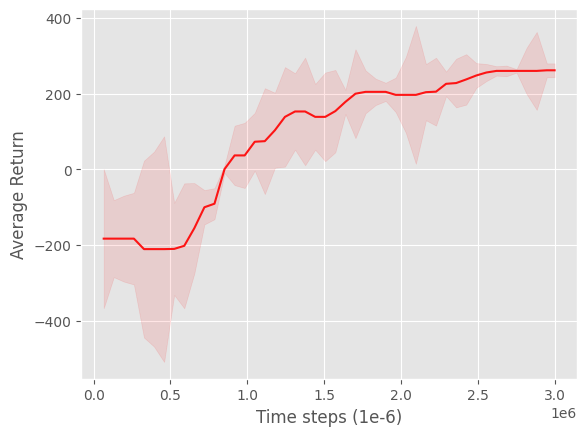

In [5]:
t = data["t"]
mean = data["average_return"]
mean = scipy.ndimage.median_filter(data["average_return"], size=AVG_FILTER_SIZE)
std = data["std_return"]
lower = mean - std
upper = mean + std

fig, ax = plt.subplots()
ax.plot(t, mean, color=COLOR, alpha=ALPHA_MEAN)
ax.fill_between(t, lower, upper, alpha=ALPHA_STD, color=COLOR)
ax.set_xlabel("Time steps (1e-6)")
ax.set_ylabel("Average Return")
plt.show()



## BipedalWalker-v3

In [6]:
data = load_data("BipedalWalker-v3")
data.head(-1)

,t,average_return,std_return
0,65536,-109.553309,15.575915
1,131072,-23.969319,NaN
2,196608,-23.627981,NaN
3,262144,-10.556248,NaN
4,327680,-24.842426,NaN
5,393216,-30.807566,NaN
6,458752,-32.221241,NaN
7,524288,-23.516063,NaN
8,589824,-24.886345,NaN
9,655360,-33.483019,NaN


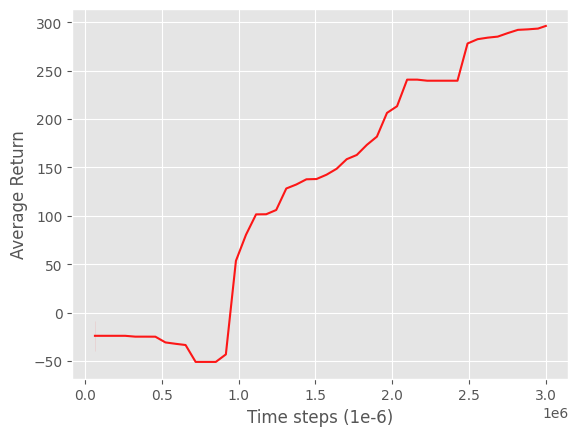

In [7]:
t = data["t"]
mean = data["average_return"]
mean = scipy.ndimage.median_filter(data["average_return"], size=AVG_FILTER_SIZE)
std = data["std_return"]
lower = mean - std
upper = mean + std

fig, ax = plt.subplots()
ax.plot(t, mean, color=COLOR, alpha=ALPHA_MEAN)
ax.fill_between(t, lower, upper, alpha=ALPHA_STD, color=COLOR)
ax.set_xlabel("Time steps (1e-6)")
ax.set_ylabel("Average Return")
plt.show()

